# Funky heatmaps for benchmark / multi-metric tables

`ov.pl.funky_heatmap` wraps the
[pyfunkyheatmap](https://github.com/omicverse/py-funkyheatmap) package — a
pure-Python port of the R [funkyheatmap](https://funkyheatmap.github.io/funkyheatmap/)
package. It produces the dynbenchmark-style figures you've seen in
[Saelens et al. (2019)](https://doi.org/10.1038/s41587-019-0071-9), the
single-cell integration benchmark, and a long list of method comparison
papers — directly from a `pandas.DataFrame`, with no R / rpy2.

This notebook walks through six worked examples on the canonical
`mtcars` dataset and ends with the side-by-side dynbenchmark figure.

> Make sure `pyfunkyheatmap` is installed: `pip install pyfunkyheatmap`.

In [1]:
import omicverse as ov
ov.style(font_path='Arial')

import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


🔬 Starting plot initialization...
Using already downloaded Arial font from: /tmp/omicverse_arial.ttf
Registered as: Arial
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1. Default heatmap from a `DataFrame`

The simplest call: pass any `DataFrame` with an `id` column. Numerical
columns become rounded "funky rectangle" glyphs whose corner radius and
fill colour encode the value; text columns become labels.

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


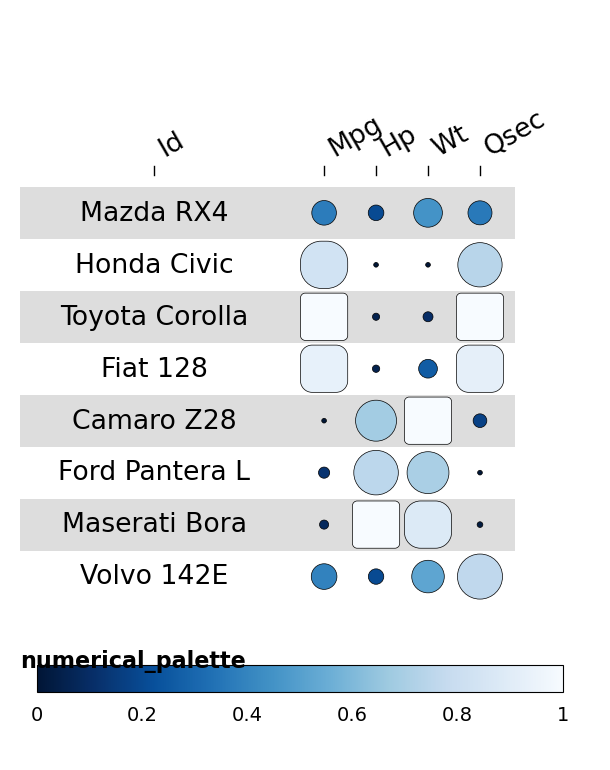

In [2]:
mtcars = pd.DataFrame({
    'id':   ['Mazda RX4','Honda Civic','Toyota Corolla','Fiat 128',
             'Camaro Z28','Ford Pantera L','Maserati Bora','Volvo 142E'],
    'mpg':  [21.0, 30.4, 33.9, 32.4, 13.3, 15.8, 15.0, 21.4],
    'hp':   [110, 52, 65, 66, 245, 264, 335, 109],
    'wt':   [2.620, 1.615, 1.835, 2.200, 3.840, 3.170, 3.570, 2.780],
    'qsec': [16.46, 18.52, 19.90, 19.47, 15.41, 14.50, 14.60, 18.60],
})
fh = ov.pl.funky_heatmap(mtcars)
fh

## 2. Mixing geoms via `column_info`

`column_info` lets you choose a different geom per column. The valid set
is ``funkyrect``, ``circle``, ``rect``, ``bar``, ``pie``, ``text`` and
``image``. Below we mix four common geoms — `text` for the method name,
`funkyrect` for accuracy, `circle` for speed, and a `bar` for memory.

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


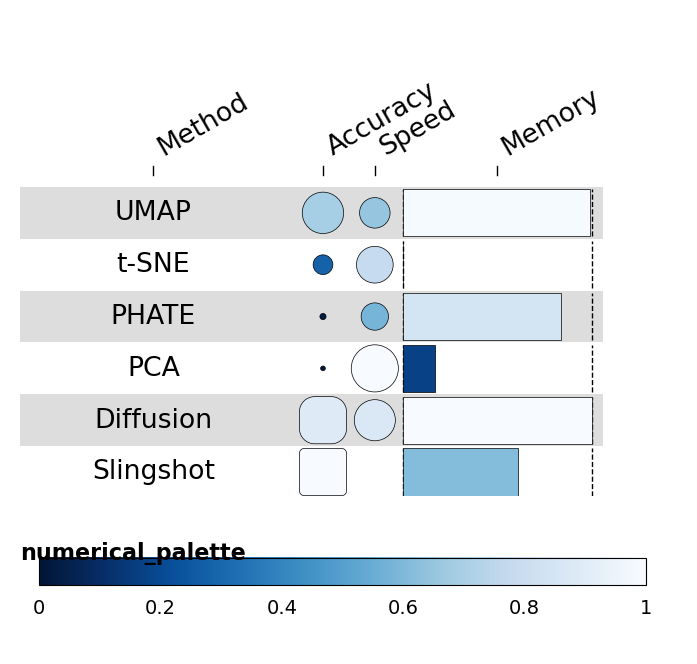

In [3]:
rng = np.random.default_rng(0)
n = 6
benchmark = pd.DataFrame({
    'id':       [f'method_{i}' for i in range(n)],
    'name':     ['UMAP','t-SNE','PHATE','PCA','Diffusion','Slingshot'],
    'accuracy': rng.uniform(0.55, 0.97, n),
    'speed':    rng.uniform(0.10, 0.95, n),
    'memory':   rng.uniform(0.20, 0.95, n),
})
column_info = pd.DataFrame({
    'id':   ['name','accuracy','speed','memory'],
    'name': ['Method','Accuracy','Speed','Memory'],
    'geom': ['text','funkyrect','circle','bar'],
})
fh = ov.pl.funky_heatmap(benchmark, column_info=column_info)
fh

## 3. Pie geoms for compositional data

If a column contains dicts of categorical proportions, that column
renders as a pie. This is the geom the dynbenchmark heatmap uses for
"method components" (e.g. uses graphs / uses MST / uses MDS).

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


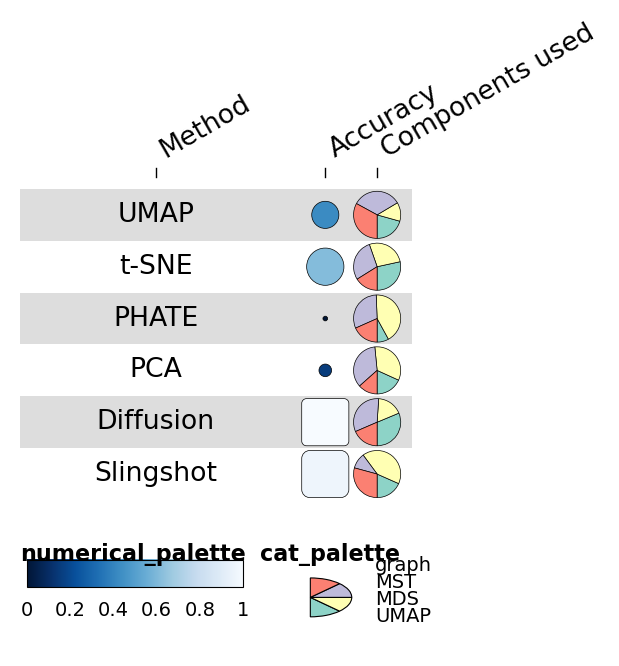

In [4]:
def _comp():
    return {k: float(rng.uniform(0, 1)) for k in ['graph','MST','MDS','UMAP']}

n = 6
df = pd.DataFrame({
    'id':         [f'm{i}' for i in range(n)],
    'name':       ['UMAP','t-SNE','PHATE','PCA','Diffusion','Slingshot'],
    'accuracy':   rng.uniform(0.55, 0.97, n),
    'components': [_comp() for _ in range(n)],
})
column_info = pd.DataFrame({
    'id':      ['name','accuracy','components'],
    'name':    ['Method','Accuracy','Components used'],
    'geom':    ['text','funkyrect','pie'],
    'palette': [None,'numerical_palette','cat_palette'],
})
fh = ov.pl.funky_heatmap(df, column_info=column_info)
fh

## 4. Column groups + per-group palettes

For dynbenchmark-style figures we want columns clustered into named
categories (`Overall`, `Resources`, `Components`), each with its own
colour palette and a coloured ribbon above the column block.

`column_groups` declares the ribbon labels; the per-column `group` key
links each column to one of those ribbons. The package draws subfigure
letters (`a)`, `b)`, `c)`, …) on the top-level ribbon automatically.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


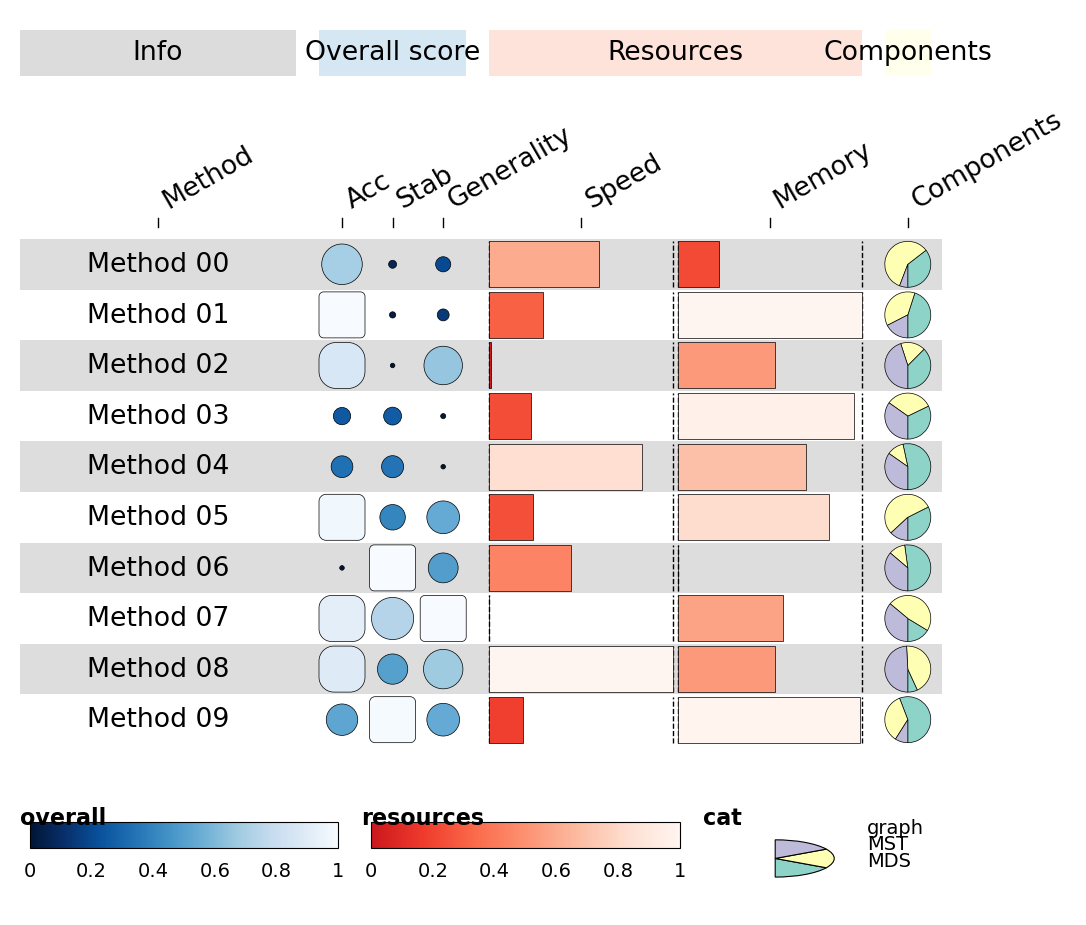

In [5]:
n = 10
rng = np.random.default_rng(7)
df = pd.DataFrame({
    'id':        [f'm{i}' for i in range(n)],
    'name':      [f'Method {i:02d}' for i in range(n)],
    'overall_a': rng.uniform(0.55, 0.97, n),
    'overall_b': rng.uniform(0.40, 0.95, n),
    'overall_c': rng.uniform(0.50, 0.95, n),
    'speed':     rng.uniform(0.10, 0.95, n),
    'memory':    rng.uniform(0.20, 0.95, n),
    'comp':      [{'graph': rng.uniform(0,1), 'MST': rng.uniform(0,1), 'MDS': rng.uniform(0,1)} for _ in range(n)],
})
column_info = pd.DataFrame({
    'id':      ['name','overall_a','overall_b','overall_c','speed','memory','comp'],
    'name':    ['Method','Acc','Stab','Generality','Speed','Memory','Components'],
    'geom':    ['text','funkyrect','funkyrect','funkyrect','bar','bar','pie'],
    'group':   ['info','overall','overall','overall','resources','resources','comp'],
    'palette': [None,'overall','overall','overall','resources','resources','cat'],
})
column_groups = pd.DataFrame({
    'group':   ['info','overall','resources','comp'],
    'level1':  ['Info','Overall score','Resources','Components'],
    'palette': [None,'overall','resources','cat'],
})
fh = ov.pl.funky_heatmap(df, column_info=column_info, column_groups=column_groups)
fh

## 5. Custom legends — discrete stops + continuous bars

By default the package adds one auto-legend per palette. For control,
pass an explicit `legends` list — each entry is a dict describing one
legend panel. Use `geom='rect'` with an explicit `labels` list to get the
discrete 5-stop scIB-style legend.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


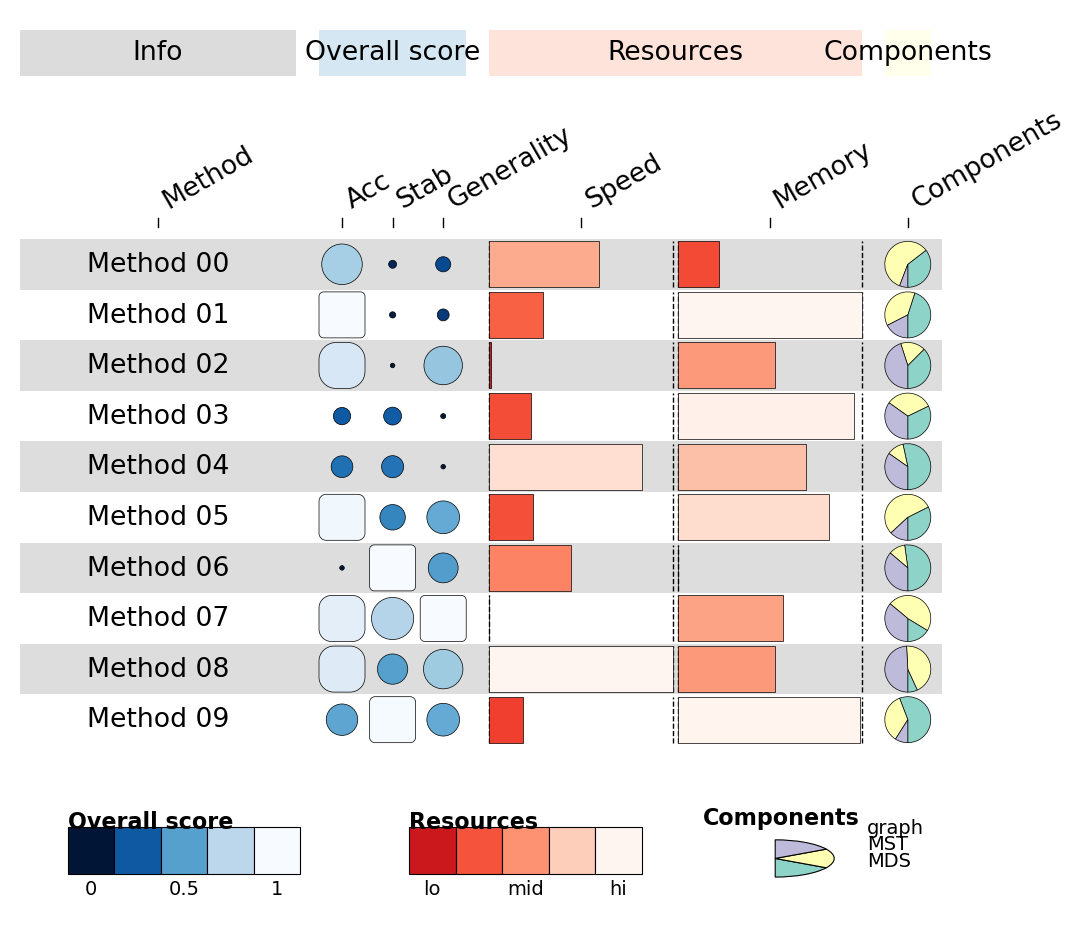

In [6]:
legends = [
    dict(palette='overall',    geom='rect',
         title='Overall score', labels=['0','','0.5','','1']),
    dict(palette='resources',  geom='rect',
         title='Resources',     labels=['lo','','mid','','hi']),
    dict(palette='cat',        geom='pie',
         title='Components',    labels=['graph','MST','MDS']),
]
fh = ov.pl.funky_heatmap(df, column_info=column_info,
                          column_groups=column_groups, legends=legends)
fh

## 6. dynbenchmark side-by-side

For the full dynbenchmark figure (51 trajectory-inference methods × 159
columns), `pyfunkyheatmap` ships the fixture and a pre-executed
[`dynbenchmark.ipynb`](https://github.com/omicverse/py-funkyheatmap/blob/main/examples/dynbenchmark.ipynb).
Here's an excerpt — see the upstream notebook for the full code.

The same `ov.pl.funky_heatmap` call accepts the full `column_info`,
`column_groups`, `row_info`, `row_groups`, and `palettes` arguments, so
you can replicate any R `funkyheatmap` figure 1:1 in Python.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


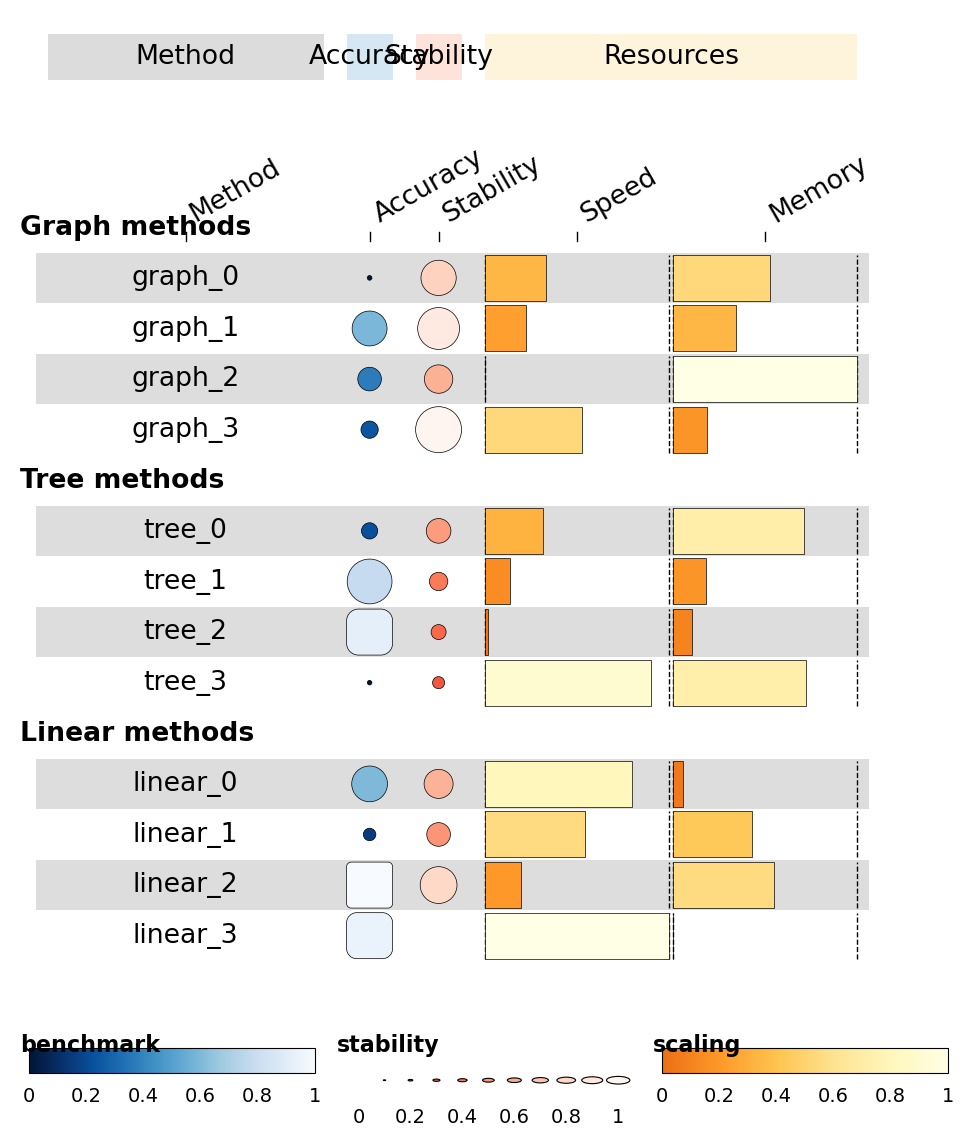

In [7]:
# small dynbenchmark-style demo with row groups
rng = np.random.default_rng(2026)
methods = (
    [f'graph_{i}' for i in range(4)] +
    [f'tree_{i}'  for i in range(4)] +
    [f'linear_{i}' for i in range(4)]
)
df = pd.DataFrame({
    'id':        methods,
    'name':      methods,
    'accuracy':  rng.uniform(0.4, 0.95, len(methods)),
    'stability': rng.uniform(0.3, 0.9,  len(methods)),
    'speed':     rng.uniform(0.1, 0.95, len(methods)),
    'memory':    rng.uniform(0.2, 0.95, len(methods)),
})
column_info = pd.DataFrame({
    'id':      ['name','accuracy','stability','speed','memory'],
    'name':    ['Method','Accuracy','Stability','Speed','Memory'],
    'geom':    ['text','funkyrect','circle','bar','bar'],
    'group':   ['info','accuracy','stability','resources','resources'],
    'palette': [None,'benchmark','stability','scaling','scaling'],
})
column_groups = pd.DataFrame({
    'group':  ['info','accuracy','stability','resources'],
    'level1': ['Method','Accuracy','Stability','Resources'],
    'palette':[None,'benchmark','stability','scaling'],
})
row_info = pd.DataFrame({
    'id': df['id'],
    'group': ['Graph methods']*4 + ['Tree methods']*4 + ['Linear methods']*4,
})
row_groups = pd.DataFrame({
    'group':  ['Graph methods','Tree methods','Linear methods'],
    'level1': ['Graph methods','Tree methods','Linear methods'],
})
fh = ov.pl.funky_heatmap(
    df, column_info=column_info, column_groups=column_groups,
    row_info=row_info, row_groups=row_groups,
    position_args=ov.pl.funky_position_arguments(col_annot_offset=3.2),
)
fh

## Summary

- `ov.pl.funky_heatmap(data, column_info=..., column_groups=..., row_info=..., row_groups=..., palettes=..., legends=...)` builds the figure.
- The result is a `FunkyHeatmap` object — call `fh.save('out.png', dpi=150)` to write the file, or access `fh.figure` for the matplotlib `Figure`.
- Every glyph type the R package supports is available: `funkyrect`, `circle`, `rect`, `bar`, `pie`, `text`, `image`.
- For the full single-cell-trajectory benchmark figure, see
  [examples/dynbenchmark.ipynb](https://github.com/omicverse/py-funkyheatmap/blob/main/examples/dynbenchmark.ipynb)
  and [examples/scIB.ipynb](https://github.com/omicverse/py-funkyheatmap/blob/main/examples/scIB.ipynb)
  in the upstream repo.

## References

- Saelens, W. et al. *A comparison of single-cell trajectory inference methods.* Nat Biotechnol 37, 547–554 (2019).
- Luecken, M.D. et al. *Benchmarking atlas-level data integration in single-cell genomics.* Nat Methods 19, 41–50 (2022).
- [py-funkyheatmap on GitHub](https://github.com/omicverse/py-funkyheatmap)